In [12]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from pyswip import Prolog
import qlpp_to_qasm
from qiskit import * 
from qiskit import qasm3
from qiskit_aer import AerSimulator
from mqt.ddsim import DDSIMProvider
import math
from qiskit.circuit.library import MCXVChain
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.visualization import plot_histogram
from IPython.display import display
%matplotlib inline

In [13]:
### --- CONFIG --- ###

## BOARD ##

# board dim
N = 4

## ----- ##


## PROLOG ##

# prolog file
prolog_filename = "queens_problem.pl"

# prolog query
prolog_query = f"queens_problem({N},C)."

## ------ ##


## QASM ##

# save-to-qasm flag
save_to_qasm = True

# load-from-qasm flag
load_from_qasm = False

# qasm filename
qasm_filename = "queens_problem.qasm"

## ---- ##


## ITERATIONS ##

# target iterations (-1 to use target probability)
k_target = -1

# target probability (1.0 for optimal iterations)
p_target = 1.0

## ------ ##


## SHOTS ##

# target shots (-1 to compute)
shots_target = 1024

## ----- ##


## PLOT ##

# draw circuit
draw_circuit = True

## ---- ##

In [14]:
# PARAMS

# single state dim
q = int(math.ceil(math.log2(N)))

# state dim
n = q * N

# search space dim
S = 2**n

# target dim
tgt_dim = N*(N-1)//2

# aux dim
aux_dim = tgt_dim - 3

# diffuser aux dim
diffuser_aux_dim = n - 3

# diffuser dim
diffuser_dim = n + diffuser_aux_dim

# ancilla dim
ancilla_dim = q + aux_dim + tgt_dim + 1

# dim 
dim = n + ancilla_dim
print("Width:", dim)

# diffuser index list
diffuser_list = None
if diffuser_aux_dim <= aux_dim:  
    diffuser_list = [*range(n), *range(n + q, n + q + diffuser_aux_dim)]
else:
    diffuser_list = [*range(n), *range(n + q, n + q + aux_dim), *range(n + q + aux_dim + 1, n + q + diffuser_aux_dim + 1)]

# solution map
solution_map = {1: 1, 2: 0, 3: 0, 4: 2, 5: 10, 6: 4, 7: 40, 8: 92, 9: 352, 10: 724, 11: 2680, 12: 14200, 13: 73712, 14: 365596, 15: 2279184, 16: 14772512, 17: 95815104, 18: 666090624, 19: 4968057848, 20: 39029188884, 21: 314666222712, 22: 2691008701644, 23: 24233937684440, 24: 227514171977364, 25: 2207893435808352, 26: 22317699616364044, 27: 234907967154122528}

# solution count
M = solution_map.get(N, "Mapping non disponibile")

# initial angle
teta_i = math.asin(math.sqrt(M/S))

# iterations
iterations = None
if (k_target == -1):
    iterations = round(math.asin(math.sqrt(p_target)) / (2 * teta_i) - 0.5)
else:
    iterations = k_target
print("Iterations:", iterations)

# final angle
teta_f = (2*iterations + 1) * teta_i

# probability
p = math.sin(teta_f) ** 2
print(f"Probability: {p:.2%}")

# shots
shots = None
if shots_target == -1:
    shots = math.ceil(25*M/p)
else:
    shots = shots_target
print("Shots:", shots)

# post-processing (if N is not a power of 2)
post_processing = False
if not ((N & (N - 1)) == 0):
    post_processing = True

Width: 20
Iterations: 8
Probability: 99.56%
Shots: 1024


In [15]:
# QUERY PROLOG
def query_prolog():
    prolog = Prolog()
    prolog.consult(prolog_filename)
    solution = next(prolog.query(prolog_query), None)

    if solution is not None:
        return solution   
    else:
        print("Nessuna soluzione trovata")
        return None

In [16]:
# EXECUTION (QASM simulation)
def execution(qc, shots=1024):
    backend = None
    qc_compiled = None
    if N == 4:
        backend = AerSimulator()
        qc_compiled = transpile(RemoveBarriers()(qc),optimization_level=3,basis_gates=['u1', 'u2', 'u3', 'x', 'cx', 'h', 's', 'sdg', 't', 'tdg'],seed_transpiler=42)
    else:
        backend = DDSIMProvider().get_backend('qasm_simulator')
        qc_compiled = transpile(RemoveBarriers()(qc),backend=backend,optimization_level=3,seed_transpiler=42)
    print("Depth:", qc_compiled.depth())
    print("Gates:", qc_compiled.count_ops())

    job = backend.run(qc_compiled, shots=shots, seed_simulator=42)
    result = job.result()
    counts = result.get_counts()
    
    return counts

In [17]:
# FILTER (post-processing)
def filter(counts):
    valid_counts = {}

    continue_flag = False
    for bitstring, count in counts.items():
        bitstring = bitstring[::-1]
        columns = []
        for i in range(0, n, q):
            col = bitstring[i:i+q]
            if int(col[::-1], 2) >=N:
                continue_flag = True
            else:
                columns.append(col) 
        if continue_flag:
            continue_flag = False
            continue 
        valid_bitstring = ''.join(columns)[::-1]
        valid_counts[valid_bitstring] = count
    
    return valid_counts

In [18]:
# SNR EVALUATION
def snr_evaluation(signal_counts, shots, space_dim):
    p_signal = signal_counts/shots
    p_signal_avg = p_signal/M
    p_noise = 1 - p_signal
    p_noise_avg = p_noise/(space_dim - M)
    snr = p_signal_avg/(p_noise_avg + 1e-15)

    return snr

In [19]:
# DIFFUSER
def diffuser(dif_qc):
    dif_qc.h(range(n))
    dif_qc.x(range(n))

    dif_qc.barrier(range(n))

    dif_qc.h(n-1)
    dif_qc.compose(MCXVChain(num_ctrl_qubits=n-1), range(diffuser_dim), inplace=True)
    dif_qc.h(n-1)

    dif_qc.barrier(range(n))

    dif_qc.x(range(n))
    dif_qc.h(range(n))

    return dif_qc

In [20]:
# ORACLE
def oracle():

    # load qasm file
    if load_from_qasm:
        oracle_qc = qasm3.load(qasm_filename)

    # generate qasm code
    else:

        # prolog query answer
        solution = query_prolog()

        # qlpp circuit
        qlpp_circuit = solution["C"]

        # qlpp -> qasm conversion
        qasm_code = qlpp_to_qasm.get_string(qlpp_circuit=qlpp_circuit, barriers=True)

        # save qasm file
        if save_to_qasm:
            with open(qasm_filename, "w", encoding="utf-8") as f:
                f.write(qasm_code)
        
        oracle_qc = qasm3.loads(qasm_code)
        

    return oracle_qc

Depth: 11778
Gates: OrderedDict([('cx', 8368), ('tdg', 3379), ('t', 3291), ('u2', 715), ('h', 417), ('u3', 296), ('u1', 256), ('x', 106), ('measure', 8)])
SNR: 32385.000 (45.103 dB)


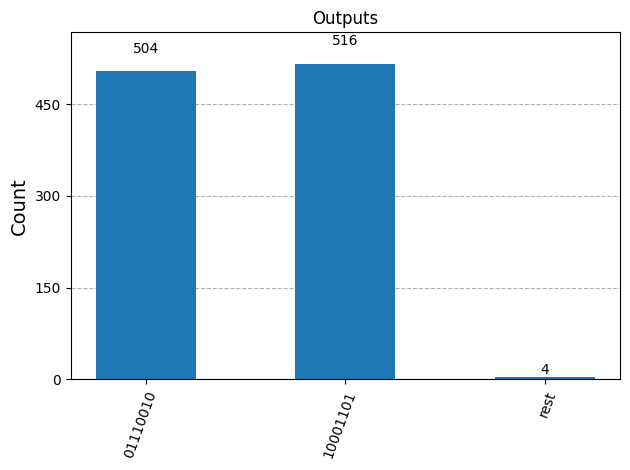

In [21]:
# QUEENS PROBLEM
def queens_problem():
    
    # circuit
    qc = QuantumCircuit(QuantumRegister(n,'q'), 
                        QuantumRegister(q,'xor'), 
                        QuantumRegister(aux_dim,'aux'), 
                        QuantumRegister(1,'ovfl'), 
                        QuantumRegister(tgt_dim,'tgt'), 
                        ClassicalRegister(n,'cbits'))

    # H on state register
    qc.h(qc.qregs[0])

    # X on xor and ovfl registers
    qc.x(qc.qregs[1][:] + qc.qregs[3][:])

    qc.barrier()
    
    # oracle
    oracle_qc = oracle()
    oracle_gate = RemoveBarriers()(oracle_qc).to_gate(label='          ORACLE          ')

    # diffuser
    dif_qc = diffuser(QuantumCircuit(diffuser_dim))
    dif_gate = RemoveBarriers()(dif_qc).to_gate(label='          DIFFUSER          ')

    # iterations
    for i in range(iterations):
        if i == 0:
            qc.compose(oracle_qc, range(dim), inplace=True)
            qc.barrier()
            qc.compose(dif_qc, diffuser_list, inplace=True)
        else:
            qc.compose(oracle_gate, range(dim), inplace=True)
            qc.barrier()
            qc.compose(dif_gate, diffuser_list, inplace=True)
        
        qc.barrier()
    
    # measurement
    qc.measure(range(n), range(n))

    return qc


qc = queens_problem()


if draw_circuit:
    display(qc.draw('mpl', style={'fontsize':18, 'subfontsize':13, 'gatetextcolor':'black'}, fold=max(70, qc.depth()//5), scale=max(0.5, 1.0 - qc.depth()/3000)))


# counts
counts = execution(qc, shots=shots)


# post-processing
if post_processing:
    counts = filter(counts)


# signal counts
signal_counts = sum(sorted(counts.values(), reverse=True)[:M])


# SNR
snr = snr_evaluation(signal_counts=signal_counts, shots=shots, space_dim=S)
snr_db = 10*math.log10(snr)
print(f"SNR: {snr:.3f} ({snr_db:.3f} dB)")


# SNR post-processing
if post_processing:
    shots_filt = sum(counts.values())
    S_filt = N**N
    snr_filt = snr_evaluation(signal_counts=signal_counts, shots=shots_filt, space_dim=S_filt)
    snr_filt_db = 10*math.log10(snr_filt)
    print(f"SNR post-processing: {snr_filt:.3f} ({snr_filt_db:.3f} dB)")


plot_histogram(counts, number_to_keep=M, title='Outputs')

In [22]:
# PRINT BOARDS
def print_boards(counts):

    solutions = sorted(counts, key=counts.get, reverse=True)[:M]

    for i, solution in enumerate(solutions):
        
        columns = [int(solution[-n:][j:j+q], 2) for j in range(0, n, q)][::-1]
        
        print(f"\nSolution {i+1}: {columns}\n")
        
        for r in range(N):
            line = " ".join("♛" if columns[r] == c else "·" for c in range(N))
            print(f"| {line} |")
        
        print()

print_boards(counts)


Solution 1: [1, 3, 0, 2]

| · ♛ · · |
| · · · ♛ |
| ♛ · · · |
| · · ♛ · |


Solution 2: [2, 0, 3, 1]

| · · ♛ · |
| ♛ · · · |
| · · · ♛ |
| · ♛ · · |

